# Examen 2 - Métodos estadísticos Bayesianos

![](https://upload.wikimedia.org/wikipedia/commons/1/18/Bayes%27_Theorem_MMB_01.jpg)

Este examen evalúa los conocimientos adquiridos en el **Módulo 3: Modelamiento Probabilístico con PyMC**, el cual marca la transición de la inferencia exacta hacia el **modelamiento probabilístico moderno** usando herramientas computacionales avanzadas.

### Objetivos de Evaluación

A lo largo de este examen se evaluarán los siguientes conceptos fundamentales:

- **Selección e implementación de distribuciones previas** apropiadas según el contexto
- **Actualización Bayesiana** usando PyMC y su interpretación
- **Análisis de datos** y selección de modelos apropiados
- **Regresión polinomial y logística** y evaluación de ajuste de modelos

### Instrucciones Generales

- Resuelva todos los puntos de manera **clara y organizada**
- Incluya **interpretaciones** de los resultados obtenidos donde se solicite
- Utilice **gráficas apropiadas** para visualizar distribuciones y relaciones
- Justifique sus **decisiones de modelado** cuando sea necesario
- El código debe ser **ejecutable y bien documentado**


### 1. Elección del dataset del examen (10 puntos)

En el primer punto, lo único que deberás hacer es elegir un dataset entre los siguientes:

- [Diagnóstico de enfermedad cardíaca](https://archive.ics.uci.edu/dataset/45/heart+disease) - Clasificación
- [Diagnóstico de cancer de mama](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) - Clasificación
- [Predicción de edad de abulón](https://archive.ics.uci.edu/dataset/1/abalone) - Regresión

Asegúrate de leer y entender la documentación del problema. También puedes obtener los datos para revisarlos antes de elegir. Para obtener los datos puedes hacer:

In [106]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [107]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
# Obtener datasets (abalone - id=1, heart disease - id=45, breast cancer - id=17)
abalone = fetch_ucirepo(id=1) 

In [109]:
abalone.data.features.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


In [110]:
abalone.data.targets

,Rings
0,15
1,7
2,9
3,10
4,7
...,...
4172,11
4173,10
4174,9
4175,10


### 2. Análisis exploratorio de datos (20 puntos)

Con el dataset elegido, lleva a cabo un análisis exploratorio para identificar posibles relaciones de las características con la salida. Asergúrate de incluir las gráficas que consideres pertinentes y no olvides **CONCLUIR** con tus observaciones.

In [111]:
X = abalone.data.features 
y = abalone.data.targets
df = pd.concat([X,y], axis=1)

,Rings
count,4177.000000
mean,9.933684
std,3.224169
min,1.000000
25%,8.000000
50%,9.000000
75%,11.000000
max,29.000000


<Axes: ylabel='Count'>

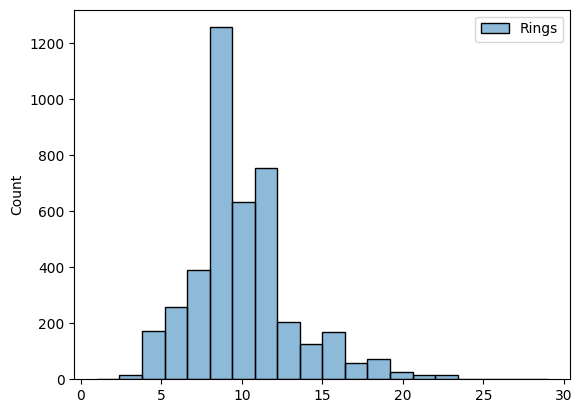

In [112]:
# Vamos a ver la distribucion de nuestra variable a predecir 
display(y.describe())
sns.histplot(y, bins=20)

Dividamos entre nuestras variables categoricas y numericas

In [113]:
numeric_columns = X.select_dtypes(include='number').columns
categoric_columns = ['Sex']
numeric_columns

Index(['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight'],
      dtype='str')

Vamos a ver como se relaciona `rings` con las variables numericas y tambien sus distribuciones

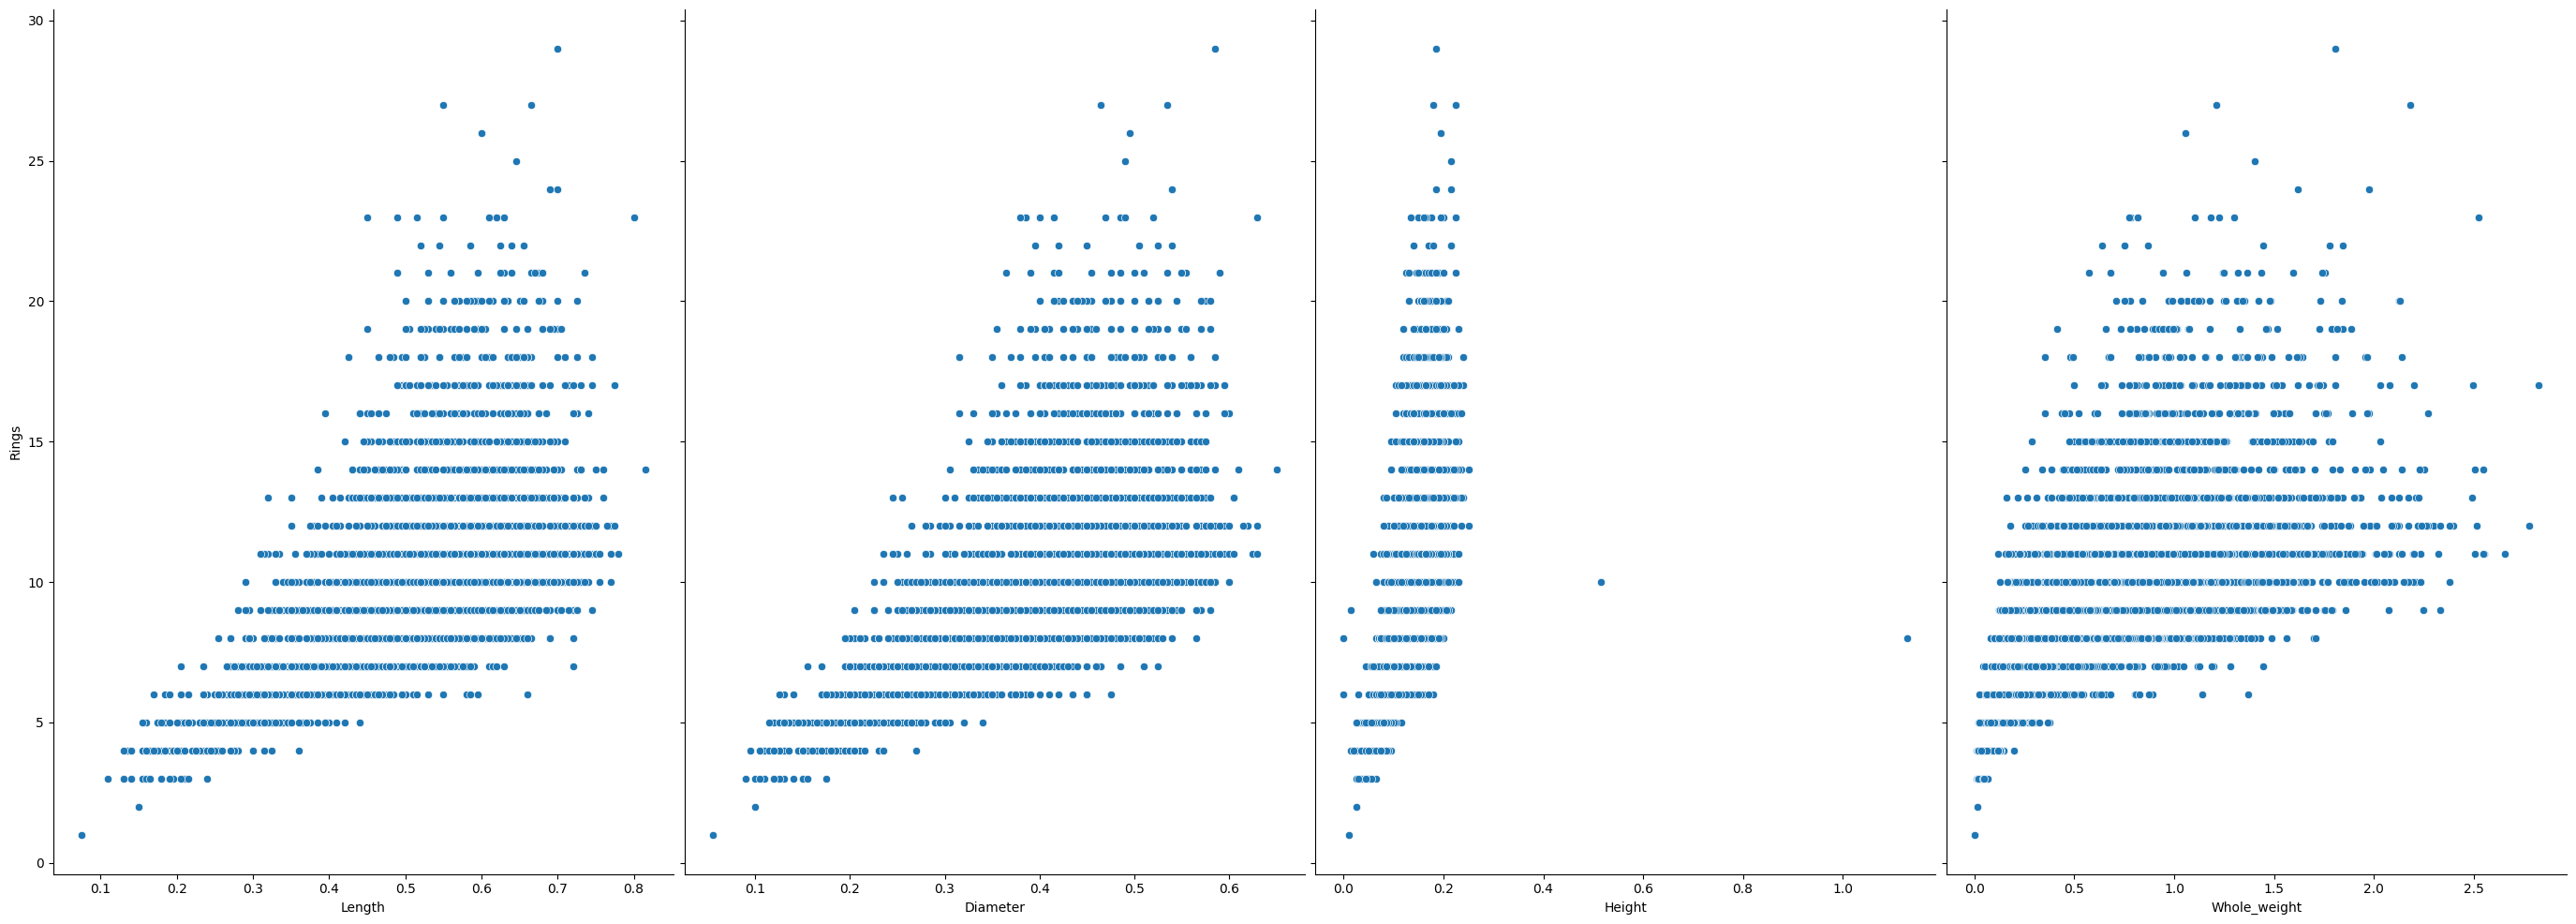

In [114]:
sns.pairplot(df, x_vars=numeric_columns[0:4], y_vars=y, height=10, aspect=0.7);

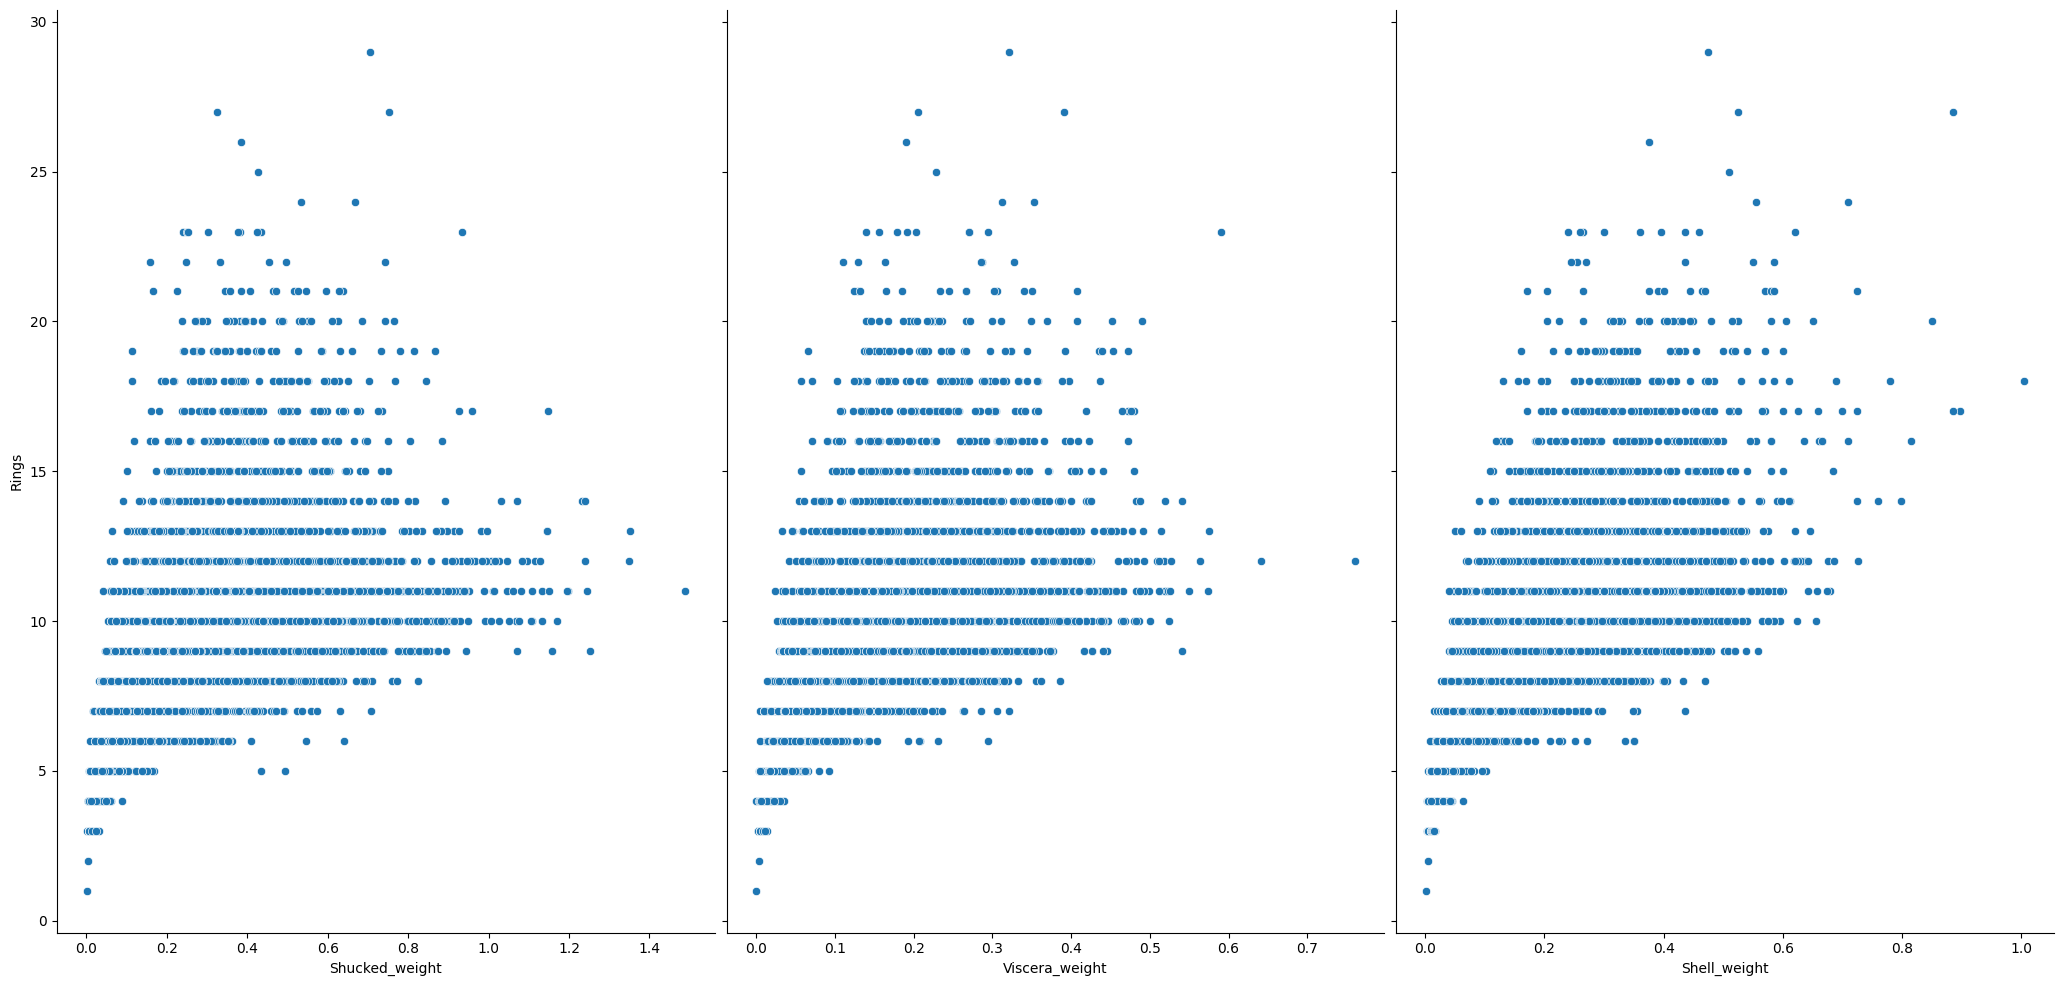

In [115]:
sns.pairplot(df, x_vars=numeric_columns[4::], y_vars=y, height=10, aspect=0.7);

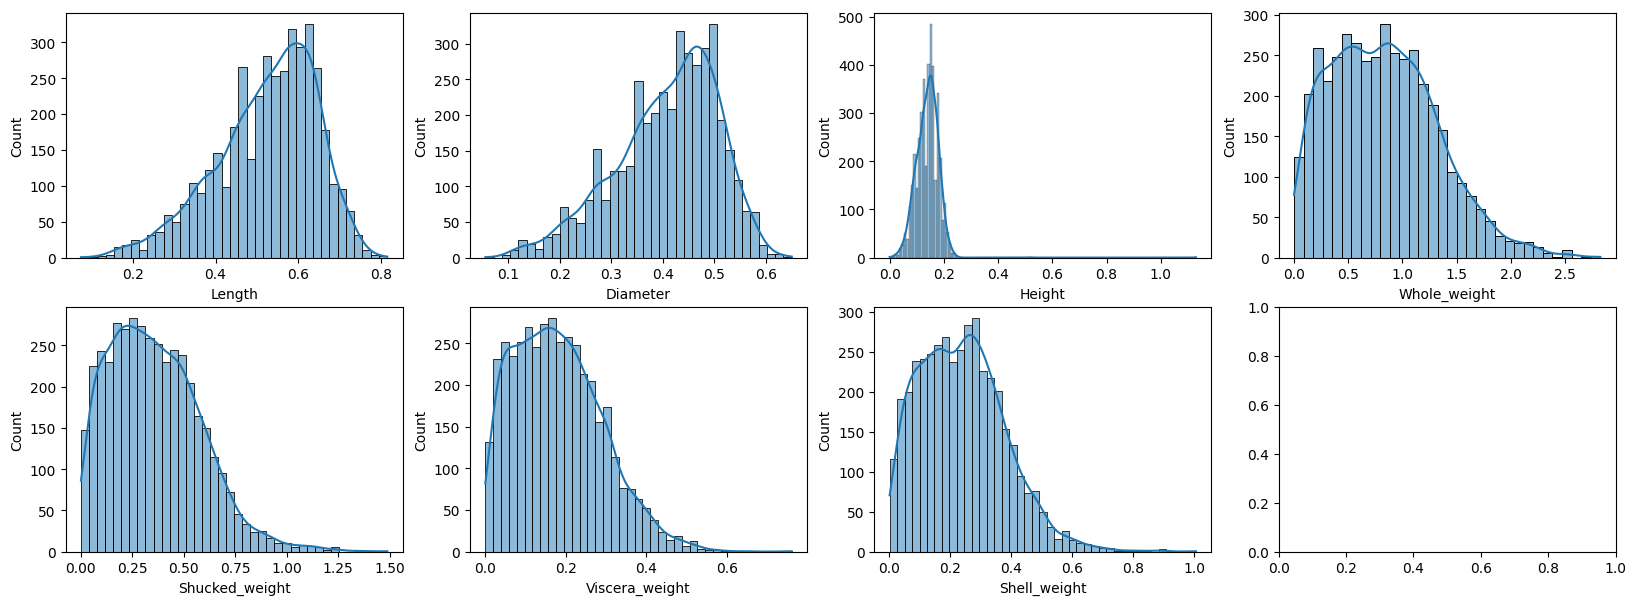

In [116]:
fig , ax = plt.subplots(nrows=2, ncols=4, figsize=(20,7))
ax = ax.flatten()

for i, col in enumerate(numeric_columns):
    sns.histplot(df[col], kde=True, ax=ax[i])

Pareciera que hay variables con mucha correlación entre ellas mismas, vamos a verlas

<Axes: >

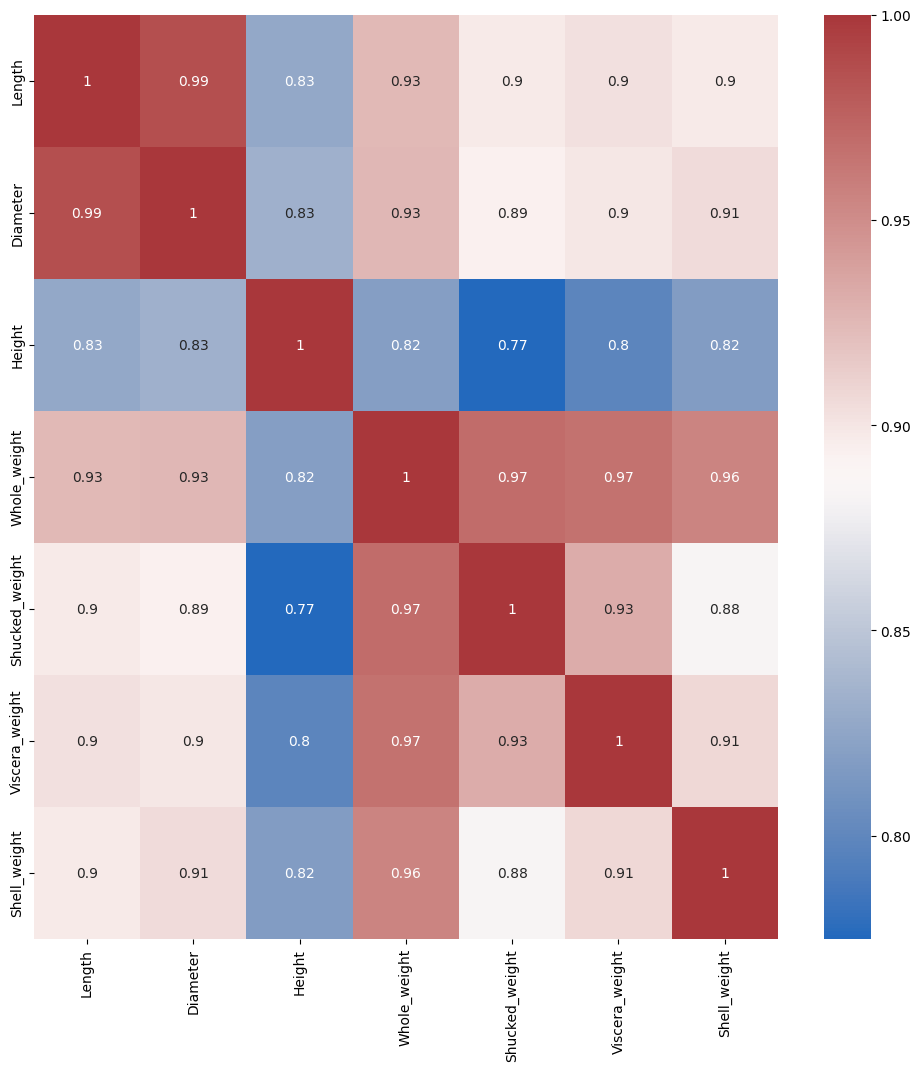

In [117]:
corr = X.corr(numeric_only=True)
plt.figure(figsize=(12,12))
sns.heatmap(corr, cmap='vlag', annot=True)

Vamos ahora a ver las categoricas

<Axes: xlabel='count', ylabel='Sex'>

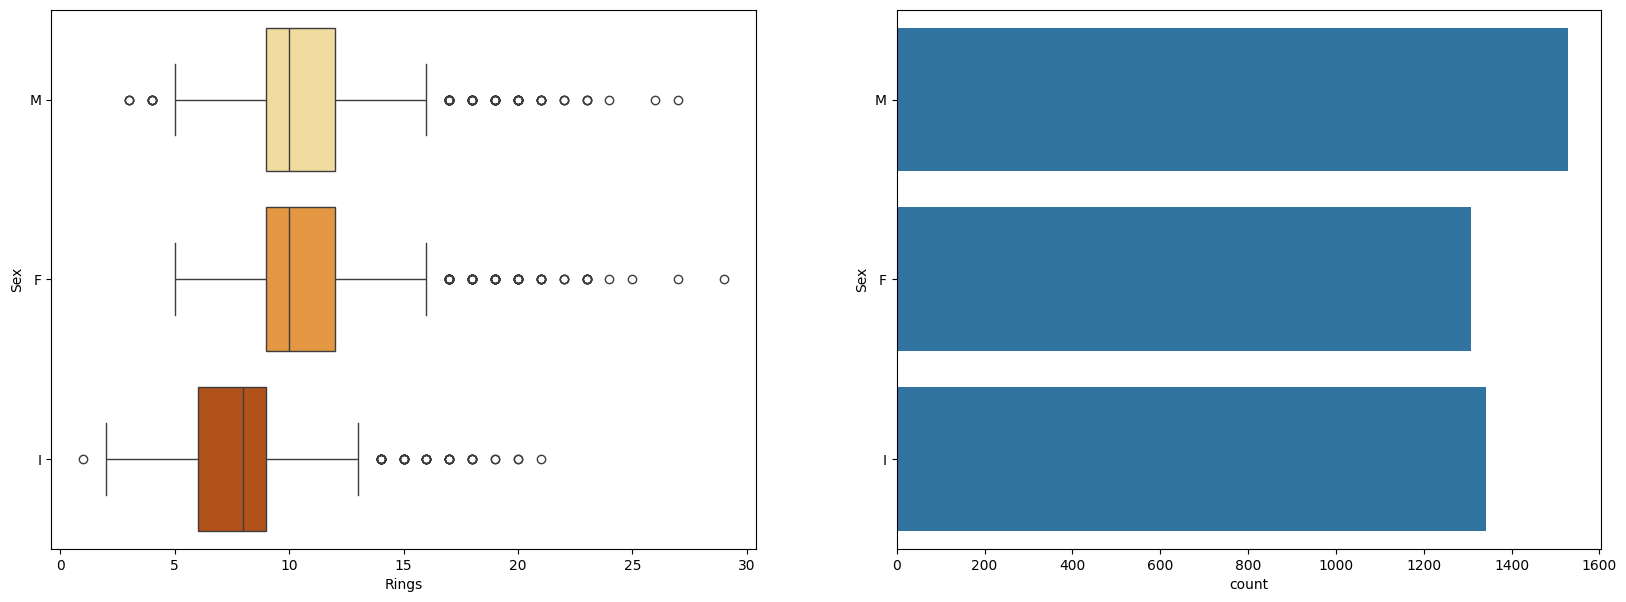

In [118]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,7))
sns.boxplot(df, x='Rings', y='Sex', hue='Sex', palette='YlOrBr', legend=False, ax=ax[0])
sns.countplot(df['Sex'], ax=ax[1])

**CONCLUSIONES**

1. **Variable objetivo (Rings):** La distribución está sesgada a la derecha, con media de alrededor 9.9 y 
   rango de 1 a 29. Existe una concentración importante entre 5 y 17 anillos aproximadamente. Esto nos puede servir para poner una previa adecuada

2. **Correlaciones:** Todas las variables numericas aparenta tener una correlacion con Rings.

3. **Sexo:** Los individuos infantiles (`I`) tieden a tener menos anillos esto porque son más jovenes,
   mientras que machos y hembras son similares entre sí. Por lo que a la hora de hacer el encodign seria bueno crear una variables que sea como si es adulto.

4. **Variable de Peso:** Las variables de peso (`Whole_weight`, `Shucked_weight`, `Viscera_weight`, 
   `Shell_weight`) están altamente correlacionadas entre sí. Por lo que nos quedaremos solo con la de `Shell_weight`.

5. **Diametro y Longitud:** Esta dos variables tienen una correlacion muy alta, porloque nos vamos a quedar con una que va a ser `Diameter`.

### 3. Modelamiento Bayesiano (20 puntos)

Con base en el punto anterior, escribe claramente tu modelo utilizando el lenguaje probabilístico que vimos en clase. Ten en mente que la modelación de un problema de regresión (variable objetivo continua) y la modelación de un problema de clasificación (variable objetivo binaria), son fundamentalmente diferentes.

Elegimos un **modelo de regresión lineal bayesiana** con las siguientes variables predictoras : `Height`, `Diameter`, `Shell_weight`, 
 y `Sex`.

$$h_i \sim Normal(\mu_i, \sigma)$$

$$\mu_i = \alpha + \beta_1 \cdot \text{Diameter}_i + \beta_2 \cdot \text{Height}_i + \beta_3 \cdot \text{Shell\_weight}_i + \beta_4 \cdot \text{Sex}_i

\begin{align}
\begin{array}{lcl}

\alpha & \sim & \text{Normal}(10, 3) \\
\beta_1 & \sim & \text{Normal}(0, 1) \\
\beta_2 & \sim & \text{Normal}(0, 1) \\
\beta_3 & \sim & \text{Normal}(0, 1) \\
\beta_4 & \sim & \text{Normal}(0, 1) \\
\sigma & \sim & \text{Uniform}(0, 3)
\end{array}
\end{align}

Escogimos la previa de alpha, por la media que nos dio en el EDA.

Las betas para las variables numéricas las pusimos normales, con media 0 y std 1. Esto porque vamos a escalar nuestras variables

La beta de sex, la pusimos con media 3 y std 1. Porque es la diferencia masomenos entre los anillos de un adulto y un infante

### 4. Validación/reselección de previas (10 puntos)

Usando simulación predictiva previa, asegúrese de que las previas elegidas tengan sentido respecto al problema. De no tenerlo, ajúste su modelo para que lo tenga.

In [119]:
import pymc as pm
import arviz as az
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler

In [120]:
# Previas
alpha = stats.norm(loc=10, scale=3)
beta1 = stats.norm(loc=0, scale=1)
beta2 = stats.norm(loc=0, scale=1)
beta3 = stats.norm(loc=0, scale=1)
beta4 = stats.norm(loc=0, scale=1)
sigma = stats.uniform(loc=0, scale=3)

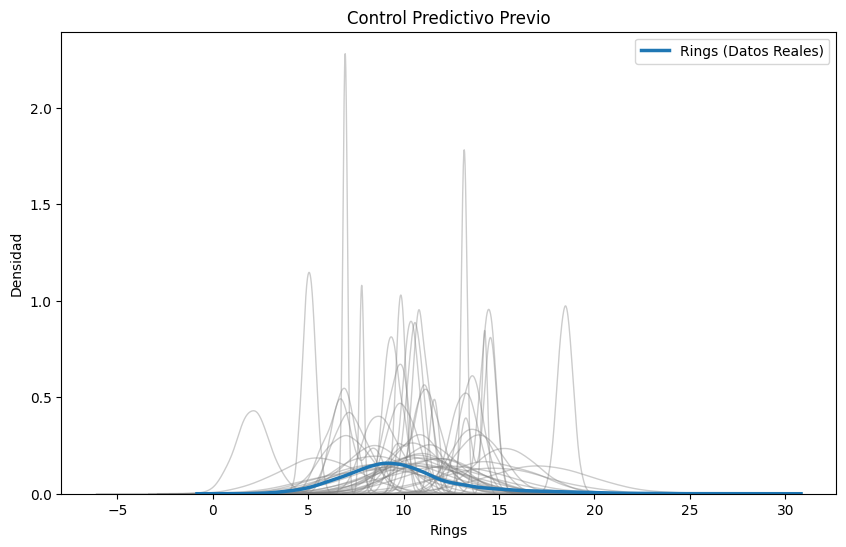

In [121]:
# Simulación previa predictiva

# Número de muestras
n_samples = 1000

sex = df['Sex'].map({'M': 0, 'F': 0, 'I': 1}).values

scaler_b1 = StandardScaler()
scaler_b2 = StandardScaler()
scaler_b3 = StandardScaler()


height = scaler_b1.fit_transform([df['Height'].values]).flatten()
diameter = scaler_b2.fit_transform([df['Diameter'].values]).flatten()
shell_w = scaler_b3.fit_transform([df['Shell_weight'].values]).flatten()


# Muestras de alpha, betas y mu
alpha_samples = alpha.rvs(size=n_samples)
beta1_samples = beta1.rvs(size=n_samples)
beta2_samples = beta2.rvs(size=n_samples)
beta3_samples = beta3.rvs(size=n_samples)
beta4_samples = beta4.rvs(size=n_samples)
sigma_samples = sigma.rvs(size=n_samples)

mu_samples = (
    alpha_samples + beta1_samples * height[:, np.newaxis] +
    beta2_samples * diameter[:, np.newaxis] + 
    beta3_samples * shell_w[:, np.newaxis] +
    beta4_samples * sex[:, np.newaxis]
    )

y_sim_samples = np.random.normal(loc=mu_samples, scale=sigma_samples)

plt.figure(figsize=(10, 6))

for i in range(50):
    sns.kdeplot(y_sim_samples[:, i], color='gray', alpha=0.4, linewidth=1, bw_adjust=1.5)


sns.kdeplot(df['Rings'], color='#1f77b4', linewidth=2.5, label='Rings (Datos Reales)')


plt.ylabel('Densidad')
plt.title('Control Predictivo Previo')
plt.legend()
plt.show()


No se ve tan mal la predictiva previa, asi que nos vamos a quedar con todas esas previas

### 5. Entrenamiento del modelo (10 puntos)

Dividir los datos en datos de entrenamiento, y datos de prueba.

Programa el modelo en **PyMC** asegurándote de incluir los datos de entrenamiento como variables mutables, para poder reemplazarlos luego por los datos de prueba. Asegúrate de manejar correctamente la(s) variable(s) categóricas, si es que las hay.

In [122]:
from sklearn.model_selection import train_test_split

In [123]:
variables = ['Height', 'Diameter', 'Shell_weight', 'Sex_code']
X['Sex_code'] = df['Sex'].map({'M': 1, 'F': 1, 'I': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X[variables], y, test_size=0.2, random_state=42
)

In [124]:
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_train[['Height', 'Diameter', 'Shell_weight']])
X_train_scaled = np.column_stack([X_numeric_scaled, X_train['Sex_code']])

In [125]:
y_train = y_train.values.ravel()  

In [126]:
with pm.Model() as linear_model:

    X_data = pm.Data('X_data', X_train_scaled)
    y_data = pm.Data('y_data', y_train)
    
    # Priors
    alpha = pm.Normal('alpha', mu=10, sigma=3)
    beta1 = pm.Normal('beta1', mu=0, sigma=1)
    beta2 = pm.Normal('beta2', mu=0, sigma=1)
    beta3 = pm.Normal('beta3', mu=0, sigma=1)
    beta4 = pm.Normal('beta4', mu=0, sigma=1)
    sigma = pm.Uniform('sigma', lower=0, upper=3)
    # Mu
    mu = (alpha
          + beta1 * X_data[:, 0] # Height
          + beta2 * X_data[:, 1] # Diameter
          + beta3 * X_data[:, 2] # Shell
          + beta4 * X_data[:, 3] # Sex
          )
    # Likelihood
    rings = pm.Normal('rings', mu=mu, sigma=sigma, observed=y_data)
    # Muestreo
    idata = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta1, beta2, beta3, beta4, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 84 seconds.


### 6. Interpretación de distribuciones posteriores (15 puntos)

Con el modelo entrenado, visualiza las distribuciones posteriores y haz una interpretación coherente con la naturaleza del problema de cada una de ellas. Escribe claramente tus **CONCLUSIONES**.

In [127]:
# Distribución posterior de los parámetros
idata.posterior

<xarray.Dataset> Size: 200kB
Dimensions:  (chain: 4, draw: 1000)
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    alpha    (chain, draw) float64 32kB 9.371 9.355 9.388 ... 9.513 9.373 9.506
    beta1    (chain, draw) float64 32kB 0.3608 0.4346 0.3851 ... 0.5116 0.3088
    beta2    (chain, draw) float64 32kB -0.08105 -0.02671 ... -0.4216 -0.2937
    beta3    (chain, draw) float64 32kB 1.537 1.554 1.544 ... 1.705 1.714 1.755
    beta4    (chain, draw) float64 32kB 0.8026 0.7938 0.7719 ... 0.9045 0.7179
    sigma    (chain, draw) float64 32kB 2.485 2.483 2.423 ... 2.461 2.473 2.448
Attributes:
    created_at:                 2026-05-04T05:25:12.606913+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              84.2899751663208
    tuning_steps:               1000

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'beta1'}>,
        <Axes: title={'center': 'beta2'}>],
       [<Axes: title={'center': 'beta3'}>,
        <Axes: title={'center': 'beta4'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

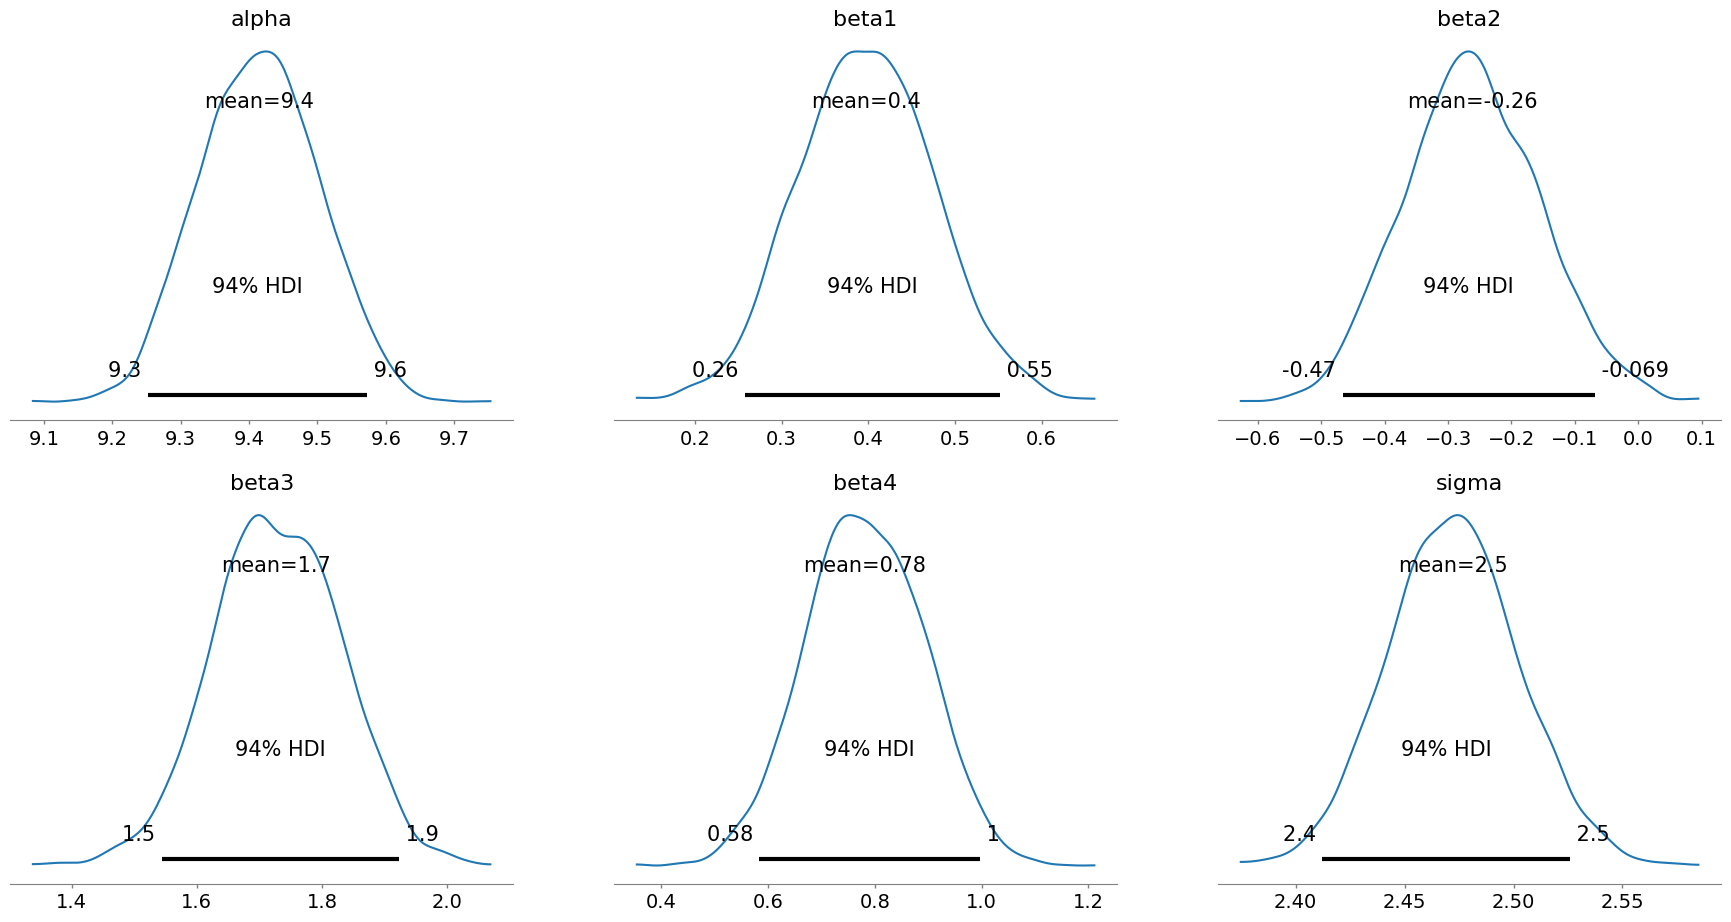

In [128]:
az.plot_posterior(idata, var_names=['alpha', 'beta1', 'beta2', 'beta3', 'beta4', 'sigma'])

In [129]:
alpha_bar = idata.posterior['alpha'].mean().values
beta1_bar = idata.posterior['beta1'].mean().values
beta2_bar = idata.posterior['beta2'].mean().values
beta3_bar = idata.posterior['beta3'].mean().values
beta4_bar = idata.posterior['beta4'].mean().values
alpha_bar, beta1_bar, beta2_bar, beta3_bar, beta4_bar

(array(9.41507462),
 array(0.39703782),
 array(-0.26193734),
 array(1.72733444),
 array(0.78106708))

**Alpha $\alpha$**
Representa el número esperado de anillos cuando todas las variables están en su valor medio. El valor de 9.4 aproximado a lo del dataset, lo que indica que el modelo está bien centrado.

**$\beta_1$ — Height**

Efecto positivo. A mayor altura del abulón, mayor
número de anillos esperados. Los abulones más altos tienden a ser
más grandes y por tanto más viejos. Cada desviación estándar adicional de altura es
**+0.39 anillos**.


**$\beta_2$ — Diameter**

Efecto negativo. Parece que esto se debe a la **multicolinealidad**: el diámetro está
altamente correlacionado con Height y Shell_weight. Por lo que seria bueno reconsiderar usar esta variable.


**$\beta_3$ — Shell_weight**

El coeficiente más grande del modelo, con efecto positivo y muy significativo.
El peso del caparazón es el mejor predictor individual de la edad del abulón: a mayor peso del
caparazón, más anillos.


**$\beta_4$ — Sex_code**

Efecto positivo. Los abulones adultos tienen en promedio
**+0.79 anillos** adicionales, los individuos clasificados como adultos biológicamente tienden a ser de mayor edad.


**$\sigma$ — Ruido del modelo**

Variabilidad que el modelo no logra explicar. Un error de ±2.5 anillos indica que las medidas
físicas capturan la tendencia general de la edad pero no toda su variabilidad.


### 7. Evaluación del modelo (15 puntos)

Evalúa el modelo entrenado, usando las métricas vistas en clase dependiendo de la naturaleza del problema que hayas elegido.

Asegúrate de **CONCLUIR** respecto de tus resultados obtenidos.

In [130]:
y_test = y_test.values.ravel()

X_num_test_scaled = scaler.transform(X_test[['Height', 'Diameter', 'Shell_weight']])
X_test_scaled = np.column_stack([X_num_test_scaled, X_test['Sex_code']])

In [131]:
with linear_model:
    pm.set_data(
        {
            'X_data': X_test_scaled,
            'y_data': y_test
        },
        coords={"obs": np.arange(len(X_train_scaled), len(X_train_scaled) + len(X_test_scaled))}
    )
    idata.extend(pm.sample_posterior_predictive(idata, predictions=True))

Sampling: [rings]


Output()

Vamos a medir los errores

In [132]:
from sklearn.metrics import mean_squared_error, r2_score

In [133]:
y_pred_samples = idata.predictions['rings'].values
y_pred_mean    = y_pred_samples.mean(axis=(0, 1))

r2   = r2_score(y_test, y_pred_mean)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_mean))

print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f} rings")


R²   : 0.4244
RMSE : 2.4961 rings


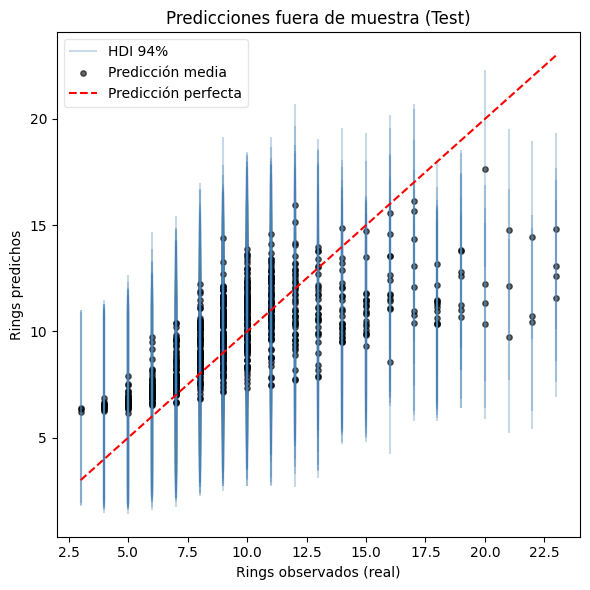

In [134]:
# Extraer predicciones como DataArray (para que az.hdi funcione correctamente)
model_preds = idata.predictions['rings']

_, ax = plt.subplots(figsize=(6, 6))

# Incertidumbre (intervalos HDI verticales)
ax.vlines(
    y_test.ravel(),
    *az.hdi(model_preds)['rings'].transpose("hdi", ...),
    alpha=0.3,
    color="steelblue",
    label="HDI 94%"
)

# Predicciones medias vs valores reales
ax.scatter(
    x=y_test.ravel(),
    y=model_preds.mean(("chain", "draw")),
    marker="o",
    color="k",
    alpha=0.6,
    s=15,
    label="Predicción media"
)

# Línea de predicción perfecta
x_min = y_test.min()
x_max = y_test.max()
ax.plot([x_min, x_max], [x_min, x_max], linestyle="--", color="red", label="Predicción perfecta")

ax.set_xlabel("Rings observados (real)")
ax.set_ylabel("Rings predichos")
ax.set_title("Predicciones fuera de muestra (Test)")
ax.legend(fontsize=10, frameon=True, framealpha=0.5)
plt.tight_layout()
plt.show()

Tenemos un $R^2$ de 0.42 eso nos dice que nuestro modelo explica el 42% de la varianza de nuestra variables a predecir `rings`.

Y nos salio que tenemos un RMSE de aproximadamente 2.5 anillos, osea que es el promedio de lo que nuestro modelo se equivoca.


En cuanto a la gráfica  

Se puede ver que para valores altos de rings (> 15): los puntos se queda por debajo de la diagonal. El modelo tiende a predecir valores menores que los reales.

### Conclusión

Un R² de 0.42 indica que el modelo lineal bayesiano captura menos de 
la mitad de la variabilidad en el número de anillos. Esto era algo que podiamos esperar ya que la relación entre las variables y la edad del abulon no tiene un relacion solo lineal. 

El RMSE de 2.5 anillos equivale a un error de aproximadamente **2.5 años** 
en la estimación de edad.



<script>
  $(document).ready(function(){
    $('div.prompt').hide();
    $('div.back-to-top').hide();
    $('nav#menubar').hide();
    $('.breadcrumb').hide();
    $('.hidden-print').hide();
  });
</script>

<footer id="attribution" style="float:right; color:#808080; background:#fff;">
Created with Jupyter by Esteban Jiménez Rodríguez.
</footer>